# DeepONet for 2D Cantilever Beam Linear Elasticity

This notebook implements a Deep Operator Network (DeepONet) to learn the solution operator mapping from load distributions to displacement fields for a cantilever beam.

**Problem Setup:**
- Cantilever beam: Length=4m, Height=1m
- Material: E=210 GPa, ν=0.3 (steel-like)
- Boundary conditions: Fixed on left edge, free on right edge
- Variable loads on top surface

In [2]:
# Install required packages (uncomment if needed)
# !pip install torch numpy matplotlib

In [3]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from matplotlib import cm
from typing import Tuple, List, Optional

print(f"PyTorch version: {torch.__version__}")
print(f"Device: {'CUDA' if torch.cuda.is_available() else 'CPU'}")

PyTorch version: 2.9.0+cpu
Device: CPU


## 1. DeepONet Architecture

DeepONet consists of two networks:
- **Branch Network**: Processes the input function (load distribution)
- **Trunk Network**: Processes spatial coordinates (x, y)

The outputs are combined via inner product to predict the solution.

In [4]:
class BranchNetwork(nn.Module):
    """Branch network processes the input function (load distribution)"""
    
    def __init__(self, sensor_count: int, hidden_dims: List[int], output_dim: int):
        super(BranchNetwork, self).__init__()
        
        layers = []
        input_dim = sensor_count
        
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(input_dim, hidden_dim))
            layers.append(nn.Tanh())
            input_dim = hidden_dim
        
        layers.append(nn.Linear(input_dim, output_dim))
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, u):
        return self.network(u)


class TrunkNetwork(nn.Module):
    """Trunk network processes the spatial coordinates"""
    
    def __init__(self, input_dim: int, hidden_dims: List[int], output_dim: int):
        super(TrunkNetwork, self).__init__()
        
        layers = []
        
        for hidden_dim in hidden_dims:
            layers.append(nn.Linear(input_dim, hidden_dim))
            layers.append(nn.Tanh())
            input_dim = hidden_dim
        
        layers.append(nn.Linear(input_dim, output_dim))
        
        self.network = nn.Sequential(*layers)
    
    def forward(self, y):
        return self.network(y)


class DeepONet(nn.Module):
    """Deep Operator Network for learning solution operators"""
    
    def __init__(
        self,
        sensor_count: int,
        branch_hidden_dims: List[int],
        trunk_hidden_dims: List[int],
        latent_dim: int,
        n_outputs: int = 2  # u_x and u_y
    ):
        super(DeepONet, self).__init__()
        
        self.n_outputs = n_outputs
        self.latent_dim = latent_dim
        
        # Create separate DeepONets for each output component
        self.branch_nets = nn.ModuleList([
            BranchNetwork(sensor_count, branch_hidden_dims, latent_dim)
            for _ in range(n_outputs)
        ])
        
        self.trunk_nets = nn.ModuleList([
            TrunkNetwork(2, trunk_hidden_dims, latent_dim)  # 2D coordinates
            for _ in range(n_outputs)
        ])
        
        # Bias terms
        self.biases = nn.ParameterList([
            nn.Parameter(torch.zeros(1))
            for _ in range(n_outputs)
        ])
    
    def forward(self, u, y):
        batch_size, n_points, _ = y.shape
        outputs = []
        
        for i in range(self.n_outputs):
            # Branch network output
            branch_out = self.branch_nets[i](u)  # [batch_size, latent_dim]
            
            # Trunk network output
            y_flat = y.reshape(-1, 2)  # [batch_size * n_points, 2]
            trunk_out = self.trunk_nets[i](y_flat)  # [batch_size * n_points, latent_dim]
            trunk_out = trunk_out.reshape(batch_size, n_points, self.latent_dim)
            
            # Inner product
            output = torch.sum(
                branch_out.unsqueeze(1) * trunk_out,
                dim=2
            ) + self.biases[i]  # [batch_size, n_points]
            
            outputs.append(output)
        
        # Stack outputs
        result = torch.stack(outputs, dim=2)  # [batch_size, n_points, n_outputs]
        return result

print("DeepONet architecture defined!")

DeepONet architecture defined!


## 2. Data Generation

Generate training data using analytical beam theory (Euler-Bernoulli beam).

In [5]:
class CantileverBeamDataGenerator:
    """Generate training data for cantilever beam"""
    
    def __init__(
        self,
        length: float = 4.0,
        height: float = 1.0,
        E: float = 210e9,  # Young's modulus (Pa)
        nu: float = 0.3,   # Poisson's ratio
        n_sensors: int = 50
    ):
        self.L = length
        self.H = height
        self.E = E
        self.nu = nu
        self.n_sensors = n_sensors
        
        # Sensor locations (along the top surface)
        self.sensor_x = np.linspace(0, self.L, n_sensors)
        self.sensor_y = np.ones(n_sensors) * self.H
        
        # Material properties
        self.D = self.E / (1 - self.nu**2)  # Plane stress
    
    def generate_random_load(self) -> np.ndarray:
        """Generate random load distribution on top surface"""
        n_modes = np.random.randint(1, 5)
        load = np.zeros(self.n_sensors)
        
        for _ in range(n_modes):
            mode_type = np.random.choice(['constant', 'linear', 'sine', 'point'])
            amplitude = np.random.uniform(-1e6, -1e4)  # Downward loads
            
            if mode_type == 'constant':
                load += amplitude * np.ones(self.n_sensors)
            elif mode_type == 'linear':
                slope = np.random.uniform(-1, 1)
                load += amplitude * (1 + slope * self.sensor_x / self.L)
            elif mode_type == 'sine':
                freq = np.random.randint(1, 4)
                load += amplitude * np.sin(freq * np.pi * self.sensor_x / self.L)
            elif mode_type == 'point':
                center = np.random.uniform(0.2 * self.L, 0.8 * self.L)
                width = np.random.uniform(0.1 * self.L, 0.3 * self.L)
                load += amplitude * np.exp(-((self.sensor_x - center) / width)**2)
        
        return load
    
    def solve_beam_deflection(self, load: np.ndarray, x_eval: np.ndarray, y_eval: np.ndarray) -> Tuple[np.ndarray, np.ndarray]:
        """Simplified analytical solution for beam deflection"""
        # Moment of inertia
        I = (self.H**3) / 12
        
        # Integrate load to get shear and moment
        dx = self.L / (self.n_sensors - 1)
        
        u_x = np.zeros_like(x_eval)
        u_y = np.zeros_like(x_eval)
        
        for i, (x, y) in enumerate(zip(x_eval, y_eval)):
            # Calculate moment at position x
            M = 0
            V = 0
            for j, (x_load, q) in enumerate(zip(self.sensor_x, load)):
                if x_load > x:
                    # Load to the right contributes to moment
                    V += q * dx
                    M += q * dx * (x_load - x)
            
            # Deflection (simplified)
            u_y[i] = M * x**2 / (2 * self.E * I)
            u_y[i] += V * x**3 / (6 * self.E * I)
            
            # Horizontal displacement (simplified)
            u_x[i] = -self.nu * (y - self.H/2) * M * x / (self.E * I)
        
        return u_x, u_y
    
    def generate_sample(self, n_points: int = 100) -> Tuple[np.ndarray, np.ndarray, np.ndarray]:
        """Generate one training sample"""
        # Generate random load
        load = self.generate_random_load()
        
        # Random evaluation points in the domain
        x_eval = np.random.uniform(0, self.L, n_points)
        y_eval = np.random.uniform(0, self.H, n_points)
        
        # Solve for displacements
        u_x, u_y = self.solve_beam_deflection(load, x_eval, y_eval)
        
        coords = np.stack([x_eval, y_eval], axis=1)
        displacements = np.stack([u_x, u_y], axis=1)
        
        return load, coords, displacements
    
    def generate_dataset(self, n_samples: int, n_points_per_sample: int = 100):
        """Generate dataset for training"""
        loads = []
        coords = []
        displacements = []
        
        for _ in range(n_samples):
            load, coord, disp = self.generate_sample(n_points_per_sample)
            loads.append(load)
            coords.append(coord)
            displacements.append(disp)
        
        return (
            np.array(loads),
            np.array(coords),
            np.array(displacements)
        )


class CantileverDataset(Dataset):
    """PyTorch Dataset for cantilever beam data"""
    
    def __init__(self, loads, coords, displacements):
        self.loads = torch.FloatTensor(loads)
        self.coords = torch.FloatTensor(coords)
        self.displacements = torch.FloatTensor(displacements)
    
    def __len__(self):
        return len(self.loads)
    
    def __getitem__(self, idx):
        return self.loads[idx], self.coords[idx], self.displacements[idx]

print("Data generation classes defined!")

Data generation classes defined!


## 3. Configuration and Data Generation

In [6]:
# Set random seeds
np.random.seed(42)
torch.manual_seed(42)

# Configuration
config = {
    'L': 4.0,
    'H': 1.0,
    'E': 210e9,
    'nu': 0.3,
    'n_sensors': 50,
    'n_train_samples': 1000,
    'n_val_samples': 200,
    'n_points_per_sample': 100,
    'batch_size': 32,
    'n_epochs': 200,
    'learning_rate': 1e-3,
    'branch_hidden_dims': [100, 100, 100],
    'trunk_hidden_dims': [100, 100, 100],
    'latent_dim': 100,
}

print("Configuration:")
for key, value in config.items():
    print(f"  {key}: {value}")

Configuration:
  L: 4.0
  H: 1.0
  E: 210000000000.0
  nu: 0.3
  n_sensors: 50
  n_train_samples: 1000
  n_val_samples: 200
  n_points_per_sample: 100
  batch_size: 32
  n_epochs: 200
  learning_rate: 0.001
  branch_hidden_dims: [100, 100, 100]
  trunk_hidden_dims: [100, 100, 100]
  latent_dim: 100


In [7]:
# Generate data
print("Generating training data...")
data_generator = CantileverBeamDataGenerator(
    length=config['L'],
    height=config['H'],
    E=config['E'],
    nu=config['nu'],
    n_sensors=config['n_sensors']
)

train_loads, train_coords, train_disps = data_generator.generate_dataset(
    config['n_train_samples'],
    config['n_points_per_sample']
)

val_loads, val_coords, val_disps = data_generator.generate_dataset(
    config['n_val_samples'],
    config['n_points_per_sample']
)

print(f"Training samples: {len(train_loads)}")
print(f"Validation samples: {len(val_loads)}")
print(f"Load shape: {train_loads.shape}")
print(f"Coords shape: {train_coords.shape}")
print(f"Displacements shape: {train_disps.shape}")

Generating training data...
Training samples: 1000
Validation samples: 200
Load shape: (1000, 50)
Coords shape: (1000, 100, 2)
Displacements shape: (1000, 100, 2)


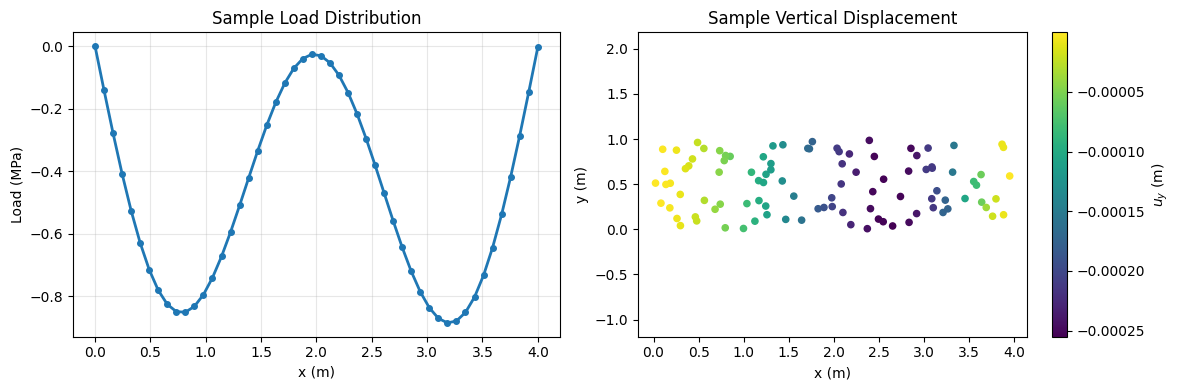

In [8]:
# Visualize sample load distribution
sample_idx = 0
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(data_generator.sensor_x, train_loads[sample_idx] / 1e6, 'o-', linewidth=2, markersize=4)
plt.xlabel('x (m)')
plt.ylabel('Load (MPa)')
plt.title('Sample Load Distribution')
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.scatter(train_coords[sample_idx, :, 0], train_coords[sample_idx, :, 1], 
            c=train_disps[sample_idx, :, 1], cmap='viridis', s=20)
plt.colorbar(label='$u_y$ (m)')
plt.xlabel('x (m)')
plt.ylabel('y (m)')
plt.title('Sample Vertical Displacement')
plt.axis('equal')

plt.tight_layout()
plt.show()

In [9]:
# Create datasets and dataloaders
train_dataset = CantileverDataset(train_loads, train_coords, train_disps)
val_dataset = CantileverDataset(val_loads, val_coords, val_disps)

train_loader = DataLoader(train_dataset, batch_size=config['batch_size'], shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=config['batch_size'], shuffle=False)

print(f"Train batches: {len(train_loader)}")
print(f"Validation batches: {len(val_loader)}")

Train batches: 32
Validation batches: 7


## 4. Model Creation and Training

In [10]:
# Create model
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"Using device: {device}")

model = DeepONet(
    sensor_count=config['n_sensors'],
    branch_hidden_dims=config['branch_hidden_dims'],
    trunk_hidden_dims=config['trunk_hidden_dims'],
    latent_dim=config['latent_dim'],
    n_outputs=2
).to(device)

n_params = sum(p.numel() for p in model.parameters())
print(f"Number of parameters: {n_params:,}")

Using device: cpu
Number of parameters: 132,002


In [11]:
# Training function
def train_epoch(model, dataloader, optimizer, criterion, device):
    model.train()
    total_loss = 0
    
    for loads, coords, displacements in dataloader:
        loads = loads.to(device)
        coords = coords.to(device)
        displacements = displacements.to(device)
        
        optimizer.zero_grad()
        predictions = model(loads, coords)
        loss = criterion(predictions, displacements)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    return total_loss / len(dataloader)

def validate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0
    
    with torch.no_grad():
        for loads, coords, displacements in dataloader:
            loads = loads.to(device)
            coords = coords.to(device)
            displacements = displacements.to(device)
            
            predictions = model(loads, coords)
            loss = criterion(predictions, displacements)
            
            total_loss += loss.item()
    
    return total_loss / len(dataloader)

print("Training functions defined!")

Training functions defined!


In [12]:
# Training loop
optimizer = optim.Adam(model.parameters(), lr=config['learning_rate'])
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.9)
criterion = nn.MSELoss()

history = {'train_loss': [], 'val_loss': []}

print("Starting training...")
for epoch in range(config['n_epochs']):
    train_loss = train_epoch(model, train_loader, optimizer, criterion, device)
    val_loss = validate(model, val_loader, criterion, device)
    
    history['train_loss'].append(train_loss)
    history['val_loss'].append(val_loss)
    
    scheduler.step()
    
    if (epoch + 1) % 20 == 0:
        print(f"Epoch {epoch+1}/{config['n_epochs']} - Train Loss: {train_loss:.6f}, Val Loss: {val_loss:.6f}")

print("Training completed!")

Starting training...
Epoch 20/200 - Train Loss: 0.000010, Val Loss: 0.000013
Epoch 40/200 - Train Loss: 0.000004, Val Loss: 0.000004
Epoch 60/200 - Train Loss: 0.000005, Val Loss: 0.000008
Epoch 80/200 - Train Loss: 0.000003, Val Loss: 0.000002
Epoch 100/200 - Train Loss: 0.000005, Val Loss: 0.000006
Epoch 120/200 - Train Loss: 0.000004, Val Loss: 0.000007
Epoch 140/200 - Train Loss: 0.000002, Val Loss: 0.000001
Epoch 160/200 - Train Loss: 0.000001, Val Loss: 0.000001
Epoch 180/200 - Train Loss: 0.000004, Val Loss: 0.000004
Epoch 200/200 - Train Loss: 0.000003, Val Loss: 0.000003
Training completed!


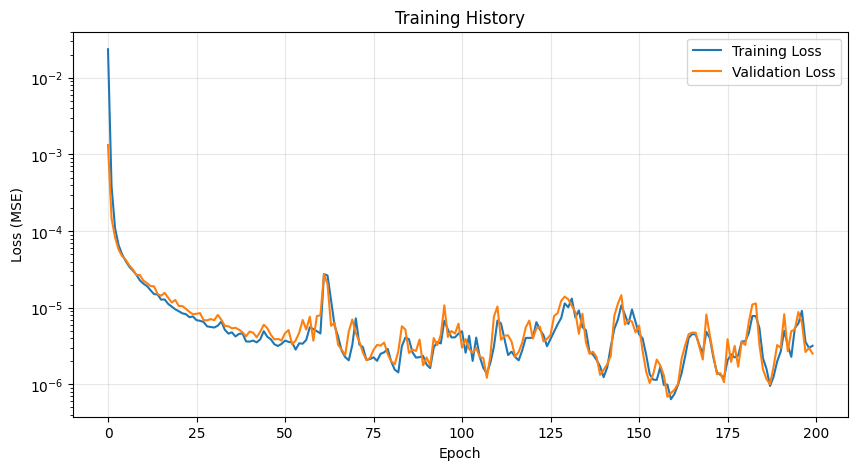

In [13]:
# Plot training history
plt.figure(figsize=(10, 5))
plt.semilogy(history['train_loss'], label='Training Loss')
plt.semilogy(history['val_loss'], label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss (MSE)')
plt.title('Training History')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## 5. Visualization and Testing

In [14]:
# Visualization function
def plot_displacement_field(model, load, data_generator, device, resolution=50):
    model.eval()
    
    # Create grid
    x = np.linspace(0, data_generator.L, resolution)
    y = np.linspace(0, data_generator.H, resolution)
    X, Y = np.meshgrid(x, y)
    
    coords = np.stack([X.flatten(), Y.flatten()], axis=1)
    coords_tensor = torch.FloatTensor(coords).unsqueeze(0).to(device)
    load_tensor = torch.FloatTensor(load).unsqueeze(0).to(device)
    
    # Predict
    with torch.no_grad():
        disp = model(load_tensor, coords_tensor)
        disp = disp.cpu().numpy()[0]
    
    u_x = disp[:, 0].reshape(resolution, resolution)
    u_y = disp[:, 1].reshape(resolution, resolution)
    u_mag = np.sqrt(u_x**2 + u_y**2)
    
    # Plot
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    
    # Load distribution
    axes[0, 0].plot(data_generator.sensor_x, load / 1e6, 'o-', linewidth=2, markersize=4)
    axes[0, 0].set_xlabel('x (m)')
    axes[0, 0].set_ylabel('Load (MPa)')
    axes[0, 0].set_title('Load Distribution')
    axes[0, 0].grid(True, alpha=0.3)
    
    # u_x
    im1 = axes[0, 1].contourf(X, Y, u_x, levels=20, cmap='RdBu_r')
    axes[0, 1].set_title('Horizontal Displacement $u_x$')
    axes[0, 1].set_xlabel('x (m)')
    axes[0, 1].set_ylabel('y (m)')
    axes[0, 1].set_aspect('equal')
    plt.colorbar(im1, ax=axes[0, 1], label='Displacement (m)')
    
    # u_y
    im2 = axes[1, 0].contourf(X, Y, u_y, levels=20, cmap='RdBu_r')
    axes[1, 0].set_title('Vertical Displacement $u_y$')
    axes[1, 0].set_xlabel('x (m)')
    axes[1, 0].set_ylabel('y (m)')
    axes[1, 0].set_aspect('equal')
    plt.colorbar(im2, ax=axes[1, 0], label='Displacement (m)')
    
    # Magnitude
    im3 = axes[1, 1].contourf(X, Y, u_mag, levels=20, cmap='viridis')
    axes[1, 1].set_title('Displacement Magnitude')
    axes[1, 1].set_xlabel('x (m)')
    axes[1, 1].set_ylabel('y (m)')
    axes[1, 1].set_aspect('equal')
    plt.colorbar(im3, ax=axes[1, 1], label='Displacement (m)')
    
    plt.tight_layout()
    plt.show()

print("Visualization function defined!")

Visualization function defined!


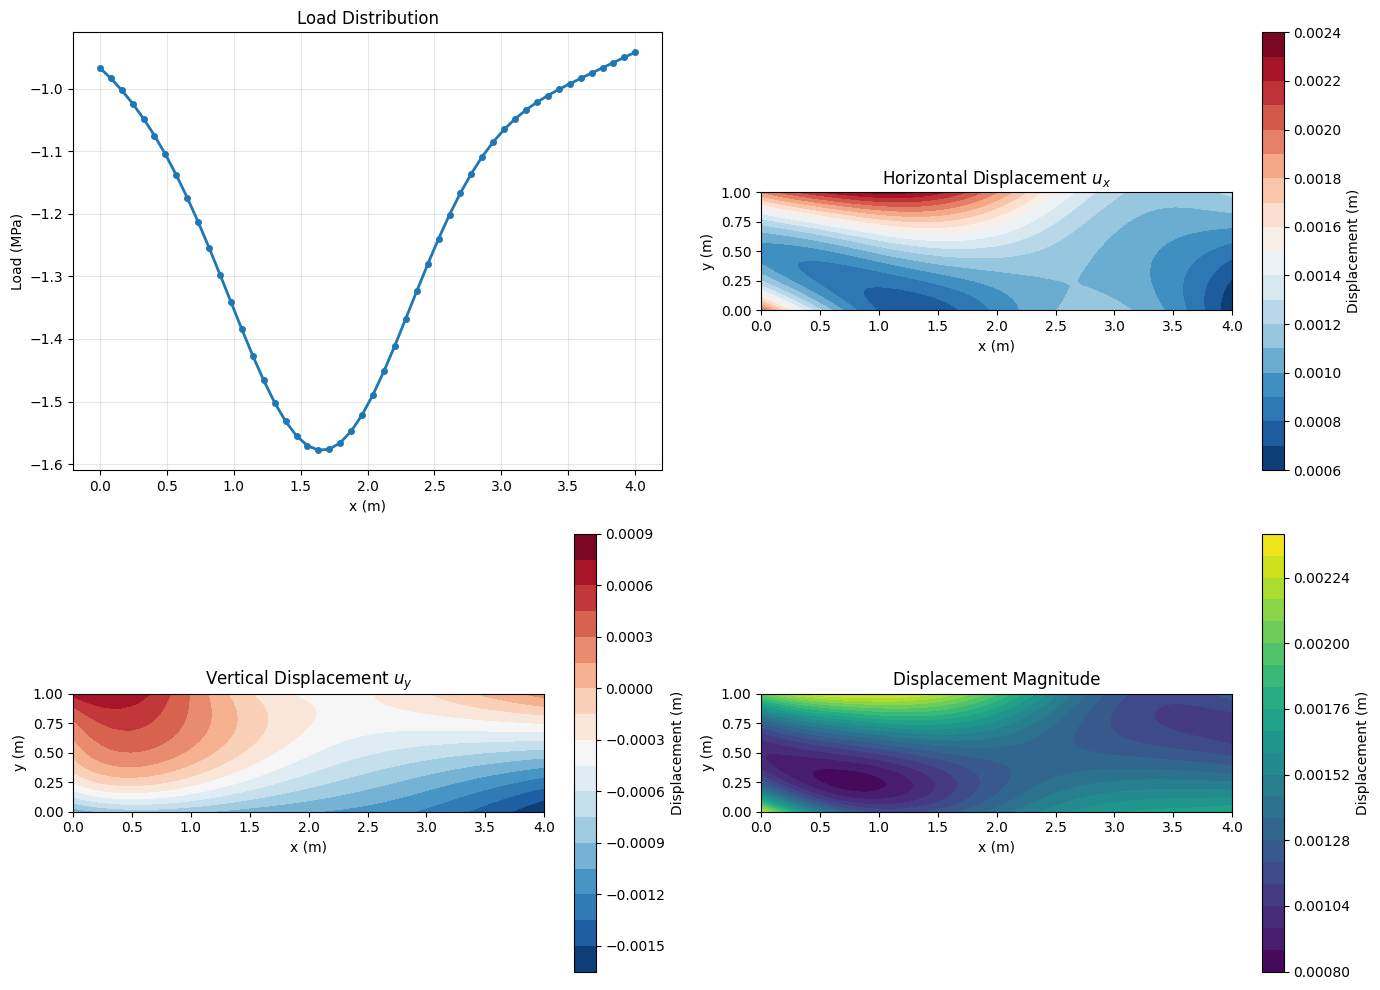

In [15]:
# Test on a new random load
test_load = data_generator.generate_random_load()
plot_displacement_field(model, test_load, data_generator, device)

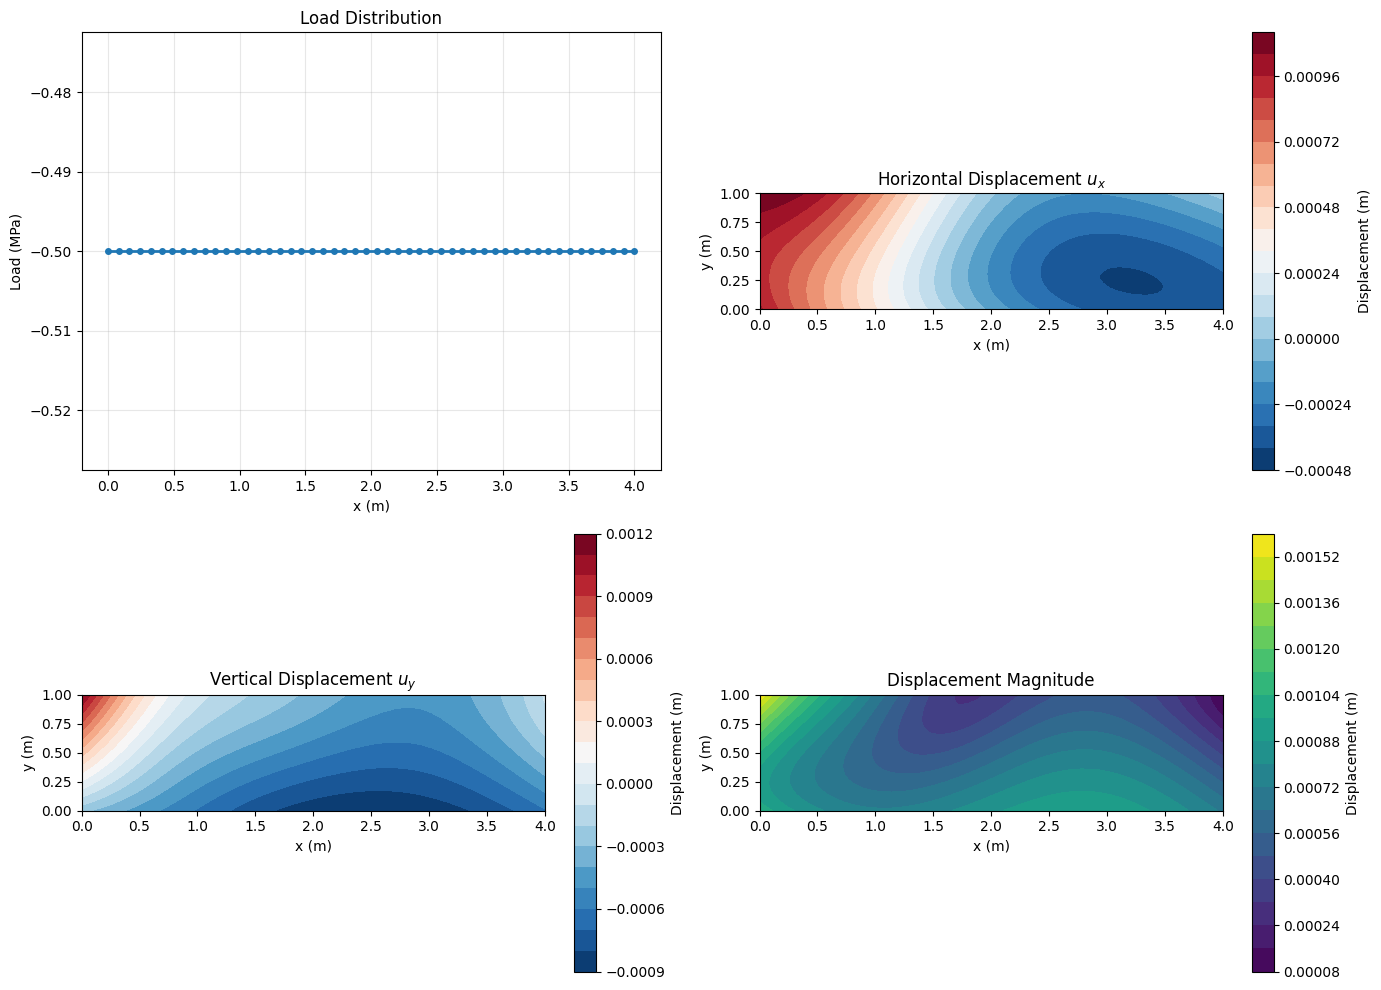

In [16]:
# Test on uniform load
uniform_load = -5e5 * np.ones(config['n_sensors'])  # -0.5 MPa uniform load
plot_displacement_field(model, uniform_load, data_generator, device)

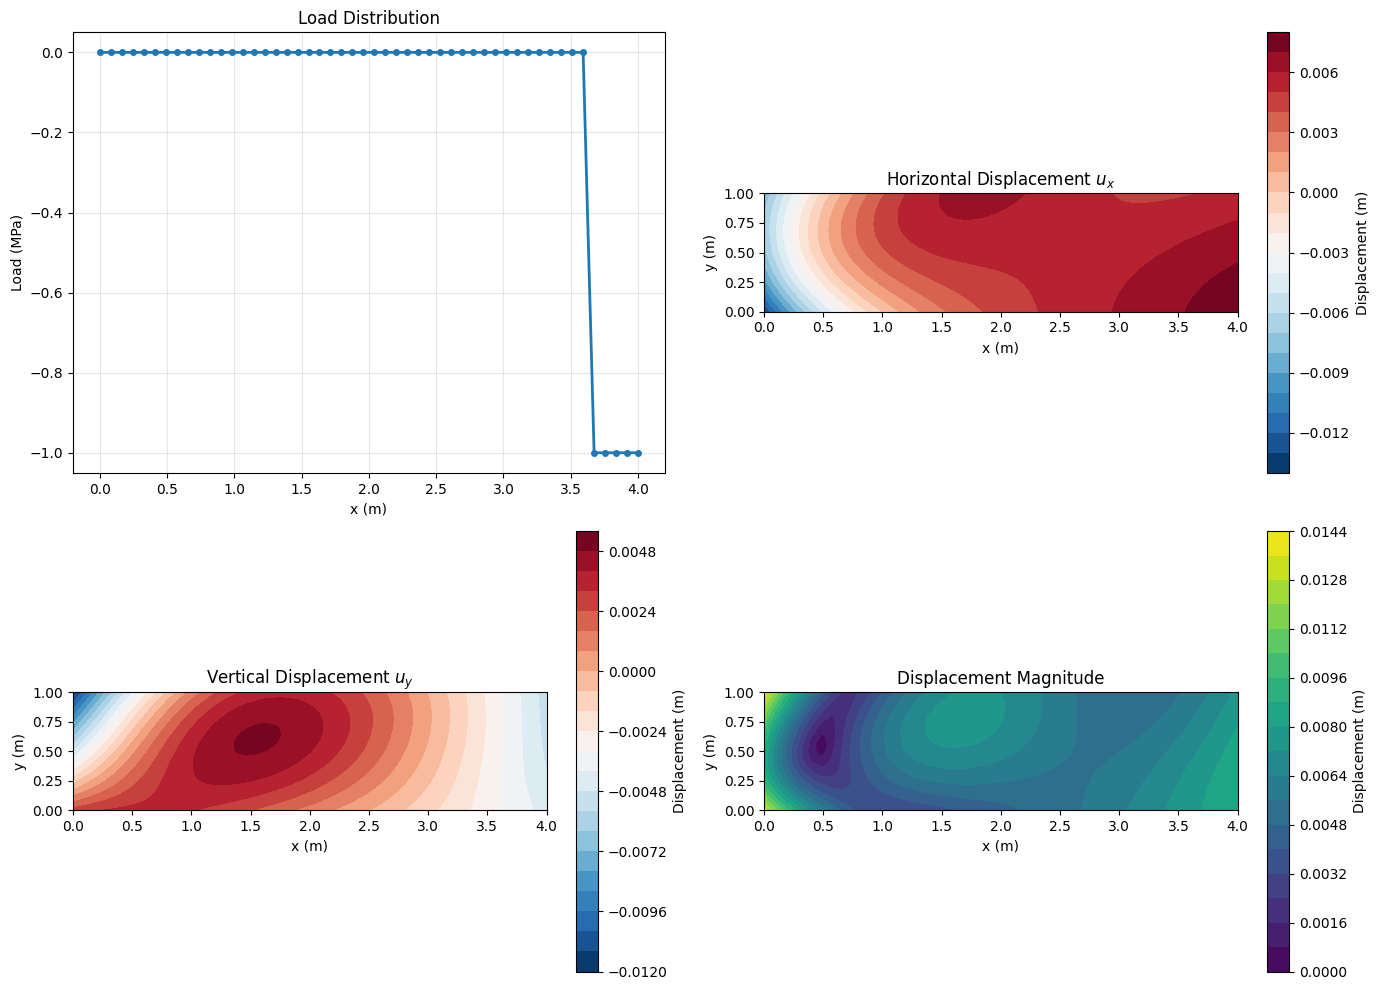

In [17]:
# Test on point load at the free end
point_load = np.zeros(config['n_sensors'])
point_load[-5:] = -1e6  # -1 MPa at the free end
plot_displacement_field(model, point_load, data_generator, device)

## 6. Save Model

In [18]:
# Save model
torch.save({
    'model_state_dict': model.state_dict(),
    'config': config,
    'history': history
}, 'deeponet_cantilever_model.pth')

print("Model saved to 'deeponet_cantilever_model.pth'")

Model saved to 'deeponet_cantilever_model.pth'


In [19]:
# To load the model later:
# checkpoint = torch.load('deeponet_cantilever_model.pth')
# model.load_state_dict(checkpoint['model_state_dict'])
# config = checkpoint['config']
# history = checkpoint['history']